# Exploration

Dieses Notebook ist fuer erste Analysen der Rohdaten und Feature-Daten gedacht.

In [5]:
from pathlib import Path
import pandas as pd
import sns

project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
raw_path = "C:/Users/keith/OneDrive/Dokumente/HTW/Untersoftware/dataScienceProject/tech_stock_prediction/experiments/exp_1_1/data/raw/tech_stocks_raw.csv"
features_path = "project_root / 'data' / 'processed' / 'tech_stocks_features.csv'"

raw_path, features_path

('C:/Users/keith/OneDrive/Dokumente/HTW/Untersoftware/dataScienceProject/tech_stock_prediction/experiments/exp_1_1/data/raw/tech_stocks_raw.csv',
 "project_root / 'data' / 'processed' / 'tech_stocks_features.csv'")

In [6]:
raw_data = pd.read_csv(raw_path, parse_dates=['Date'])
raw_data.head()

,Date,Adj Close,Close,High,Low,Open,Volume,Ticker
0,2019-01-02,37.469193,39.480000,39.712502,38.557499,38.722500,148158800,AAPL
1,2019-01-02,224.570007,224.570007,226.169998,219.000000,219.910004,2784100,ADBE
2,2019-01-02,18.830000,18.830000,19.000000,17.980000,18.010000,87148700,AMD
3,2019-01-02,76.956497,76.956497,77.667999,73.046501,73.260002,159662000,AMZN
4,2019-01-02,52.301720,52.734001,53.039501,51.264000,51.360001,31868000,GOOGL


In [7]:
raw_data.groupby('Ticker')['Close'].describe()

,count,mean,std,min,25%,50%,75%,max
Ticker,,,,,,,,
AAPL,1862.0,157.053633,64.977097,35.547501,119.292501,157.849998,200.795006,312.510010
ADBE,1862.0,422.276509,112.213795,215.699997,333.664993,417.244995,504.807487,688.369995
AMD,1862.0,109.373179,65.080863,17.049999,72.519999,98.115002,140.740002,518.090027
AMZN,1862.0,153.293624,47.585360,75.014000,108.110874,156.479996,184.067505,274.989990
GOOGL,1862.0,135.051929,70.612444,51.273499,85.904875,123.505001,162.727497,402.619995
INTC,1862.0,42.943926,15.248473,18.129999,30.622500,44.855000,52.942500,129.440002
META,1862.0,352.954205,186.850460,88.910004,196.007504,294.419998,507.687508,790.000000
MSFT,1862.0,301.588512,114.168716,97.400002,214.597500,289.919998,406.635002,542.070007
NVDA,1862.0,57.772322,63.144723,3.199750,12.848312,22.695000,110.552500,235.740005


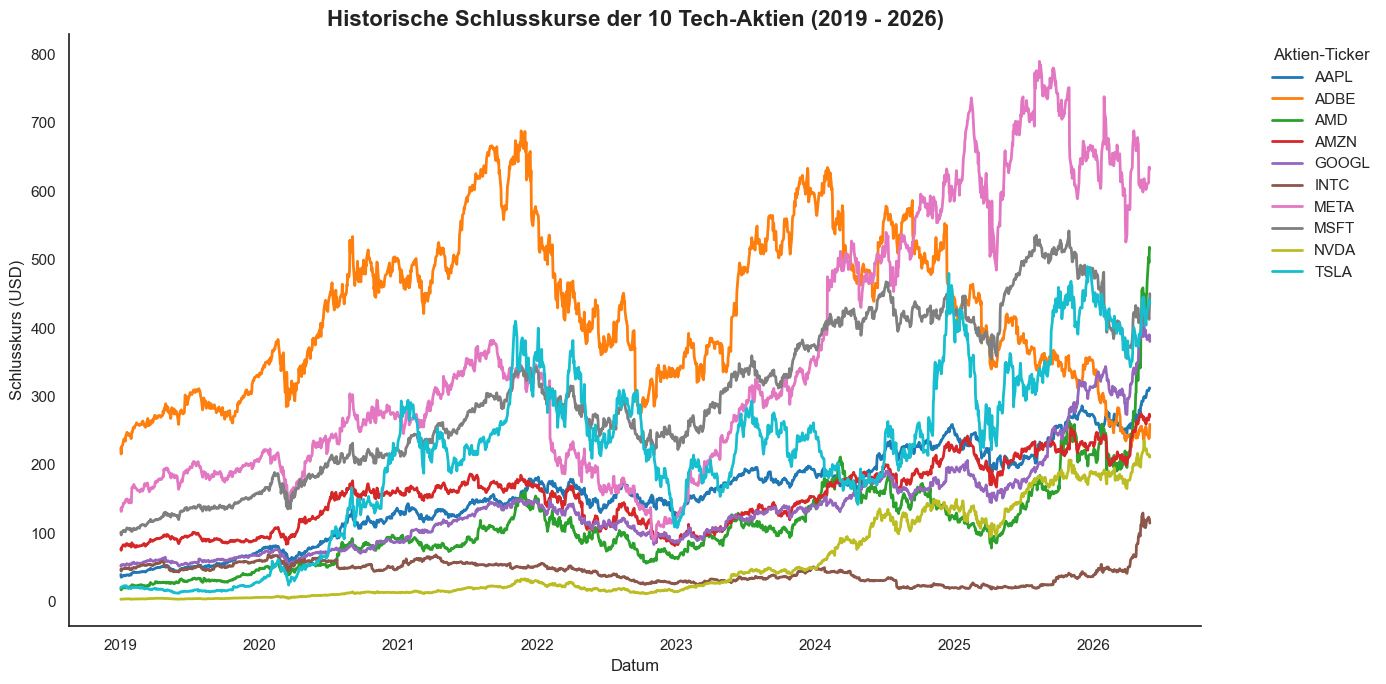

In [11]:

# Rohdaten - nicht unsere Daten
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Wir schalten das Gitter komplett ab für einen absolut reinen, weißen Hintergrund
sns.set_theme(style="white")

# 2. Erstellen der Figur mit rein weißem Hintergrund für die gesamte Grafik
plt.figure(figsize=(14, 7), facecolor='white')

# 3. Linien plotten mit einer sehr klaren, kontrastreichen Farbpalette
# 'tab10' sorgt dafür, dass sich die 10 Aktien farblich perfekt voneinander abheben
ax = sns.lineplot(
    data=raw_data,
    x='Date',
    y='Close',
    hue='Ticker',
    palette='tab10',
    linewidth=2.0
)

# 4. Titel und Beschriftungen in einem gut lesbaren Dunkelgrau
plt.title('Historische Schlusskurse der 10 Tech-Aktien (2019 - 2026)', fontsize=16, fontweight='bold', color='#222222')
plt.xlabel('Datum', fontsize=12, color='#222222')
plt.ylabel('Schlusskurs (USD)', fontsize=12, color='#222222')

# 5. Legende perfekt auf weißem Hintergrund platzieren
plt.legend(title='Aktien-Ticker', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# 6. Unnötige schwarze Rahmenlinien oben und rechts entfernen (wirkt noch offener und heller)
sns.despine()

plt.tight_layout()
plt.show()

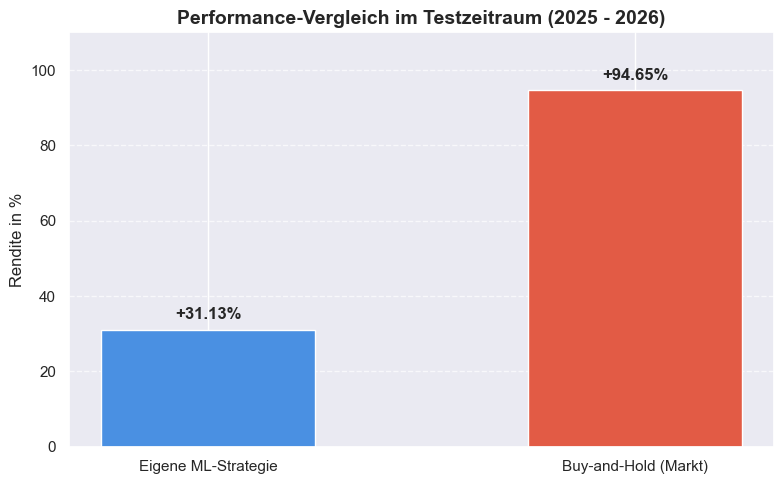

In [9]:
import matplotlib.pyplot as plt
# Gewinne nach unseren Modell vs. Tatsächlichen Gewinn
# Echte Ergebnisse aus eurem Terminal-Durchlauf eintragen
ergebnisse = {
    'Eigene ML-Strategie': 31.13,
    'Buy-and-Hold (Markt)': 94.65
}

# Diagramm erstellen
plt.figure(figsize=(8, 5))
farben = ['#4A90E2', '#E25B45'] # Blau für euch, Rot für den Markt

bars = plt.bar(ergebnisse.keys(), ergebnisse.values(), color=farben, width=0.5)

# Prozentzahlen oben auf die Balken schreiben
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f"+{yval}%", ha='center', va='bottom', fontweight='bold')

plt.title('Performance-Vergleich im Testzeitraum (2025 - 2026)', fontsize=14, fontweight='bold')
plt.ylabel('Rendite in %', fontsize=12)
plt.ylim(0, 110) # Platz nach oben lassen für die Beschriftung
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()